# Getting Started with Data

__Author(s):__ Bernard Chang

__Last Update:__ Apr. 2026

Copyright © 2026 Digital Porous Media Team. All rights reserved.

---

## Overview

This notebook introduces two ways to access image data for the tutorial notebooks in this course:

1. **Registry data (tutorial datasets)**: Pre-selected, standardized datasets hosted on the [Digital Porous Media Portal](https://digitalporousmedia.org) (DPMP). These are curated for teaching and automatically downloaded and cached.

2. **Your own data**: If you want to analyze your own images or data from DPMP that is not in the tutorial registry, you can copy files to your work directory and load them by path.

Both approaches result in NumPy arrays that you can then process using the same tools and methods throughout this course.

## Import packages

This notebook uses TIFF files to exemplify the general process of loading and preparing image data for use in these tutorials. The same workflow applies to other file formats, only the image-reading function needs to be adjusted.  

This notebook depends on **numpy, matplotlib, and tifffile.** 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from pathlib import Path
import sys

# Add parent directory to path so we can import utils
sys.path.insert(0, str(Path.cwd().parent))

## Method 1: Load Data from the Tutorial Registry

These tutorials include a registry of standardized images that are published as a [dataset on DPMP](https://digitalporousmedia.org/published-datasets/drp.project.published.DRP-1112v5). This registry **ONLY** covers the example material used in this course. If you want to use your own data, or other data from DPMP, you will need to follow Method 2.

### How it works

- Each dataset has a name (e.g., `"sandpack"`, `"beadpack"`, `"mtgambier"`)
- The first time you call `load_sample(name)`, the function:
  1. Looks up the name in `utils/registry.json`
  2. Downloads the file from DPMP's Corral to your local `./dpm_cache/` directory
  3. Returns a NumPy array
- On subsequent calls, the cached file is loaded (no download)

### Example: Load a 3D image from the registry

In [ ]:
from utils.dataloader import load_sample

# Load sandpack dataset from registry
# First run will download; subsequent runs will use cache
image = load_sample("sandpack")

print(f"Shape: {image.shape}")
print(f"Data type: {image.dtype}")
print(f"Value range: [{image.min()}, {image.max()}]")

### Quick preview of the registry data

In [ ]:
# For 3D data, display a middle slice
if image.ndim == 3:
    mid_slice = image[image.shape[0] // 2, :, :]
    title_str = f"sandpack — z-slice at depth {image.shape[0] // 2}"
else:
    mid_slice = image
    title_str = "sandpack"

plt.figure(figsize=(8, 8))
plt.imshow(mid_slice, cmap='gray')
plt.axis('off')
plt.title(title_str)
plt.tight_layout()
plt.show()

### Available datasets in the tutorial registry

The registry contains 26 curated datasets:

| Category | Datasets |
|----------|----------|
| **Engineered** | `beadpack` |
| **Sandstones** | `castlegate`, `sandpack`, `sandstone_2d_high_res`, `sandstone_2d_low_res` |
| **Carbonates** | `estaillades`, `ketton_original`, `ketton_filtered` |
| **Other rocks** | `mtgambier`, `rice`, `quartz`, `finney_pack`, `north_sea_sem` |
| **Micromodels** | `berea_200_micromodel`, `berea_500_micromodel` |
| **Thin sections** | `miocene_thin_section` |
| **Time series** | `glass_bead_drainage_t1`, `glass_bead_drainage_t2`, `glass_bead_drainage_t5`, `glass_bead_drainage_t7`, `glass_bead_drainage_t9`, `glass_bead_drainage_t10`, `glass_bead_drainage_t11`, `glass_bead_drainage_t12` |
| **Simulation fields** | `velocity_x`, `velocity_y`, `velocity_z` |

**Want to use a different dataset?** See Method 2 below.

## Method 2: Transfer Your Own Data

If you want to use data from another DPMP Dataset, or your own data, you'll first need to move it to a location accessible from this notebook.

### Where to put your data

If you are working on **DPMP's JupyterHub**, your TACC `$WORK` directory (on Lonestar6) is mounted as:

```
/home/jovyan/work/ls6
```

If you are working **locally** (on your own computer), store data anywhere on your machine and provide the full path.

### Three ways to get data to your work directory

#### Option A: Copy from DPMP portal UI (on-portal, no coding required)

1. Log in to [digitalporousmedia.org](https://digitalporousmedia.org)
2. In your account dashboard, go to ``Data Files`` -> ``Published Datasets``. This will list all published projects on DPMP. In this pane, navigate to the image file you want to work with.

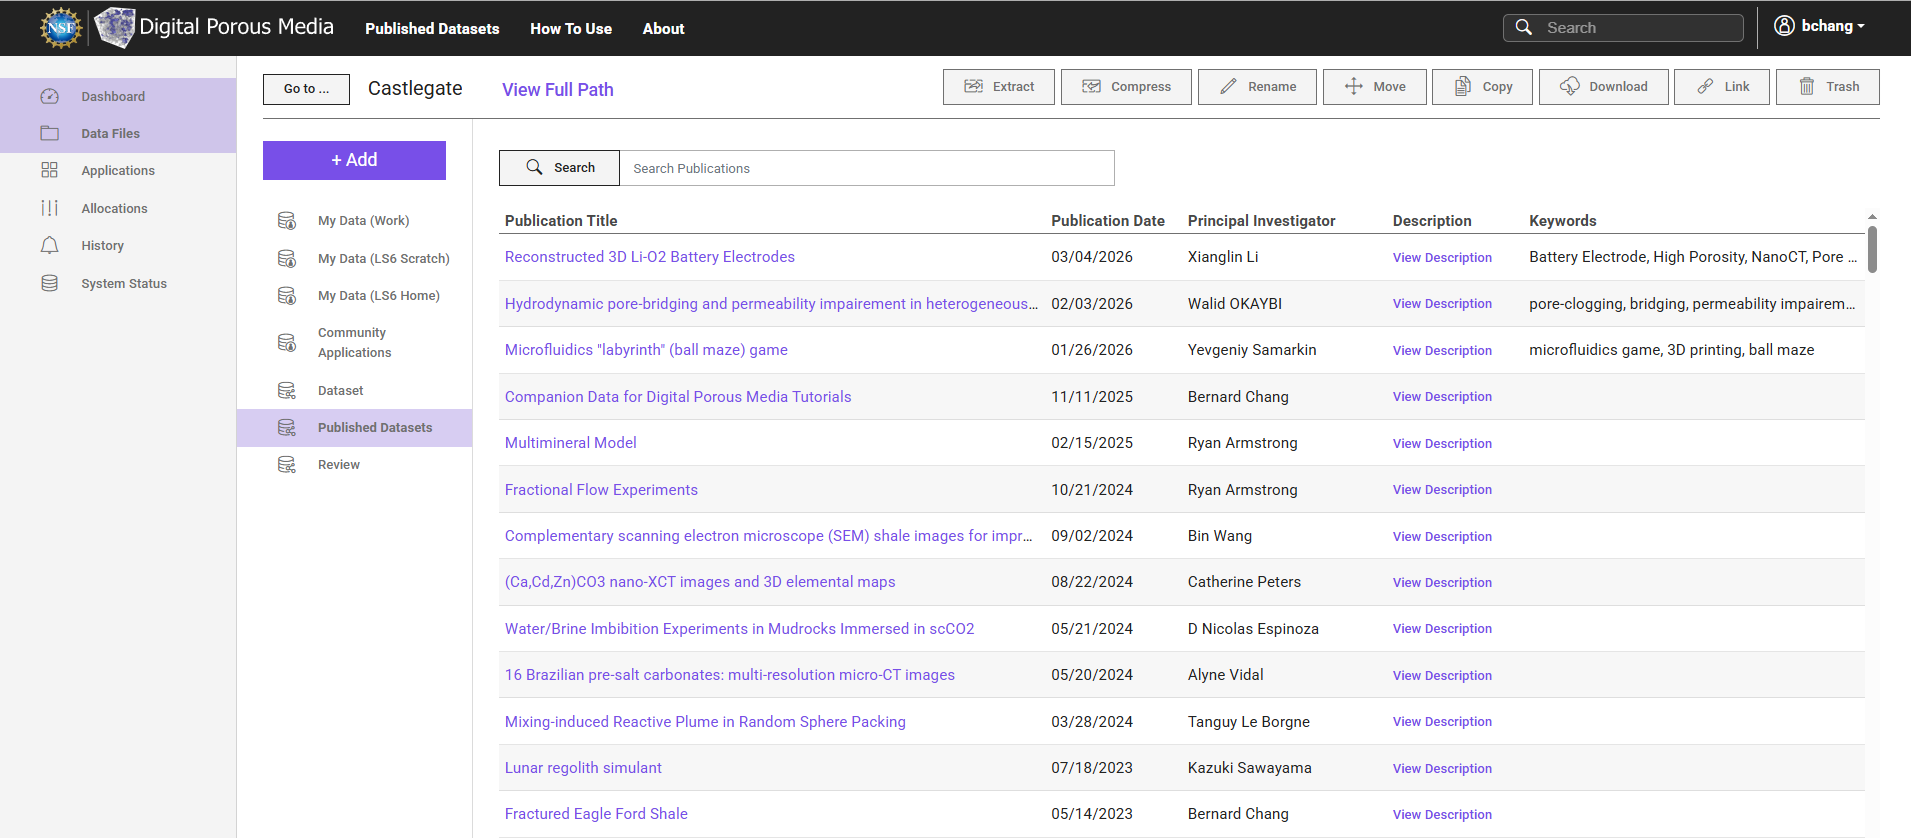

3. Once you have navigated to the image file you want to work with, select the file and use the**Copy** button

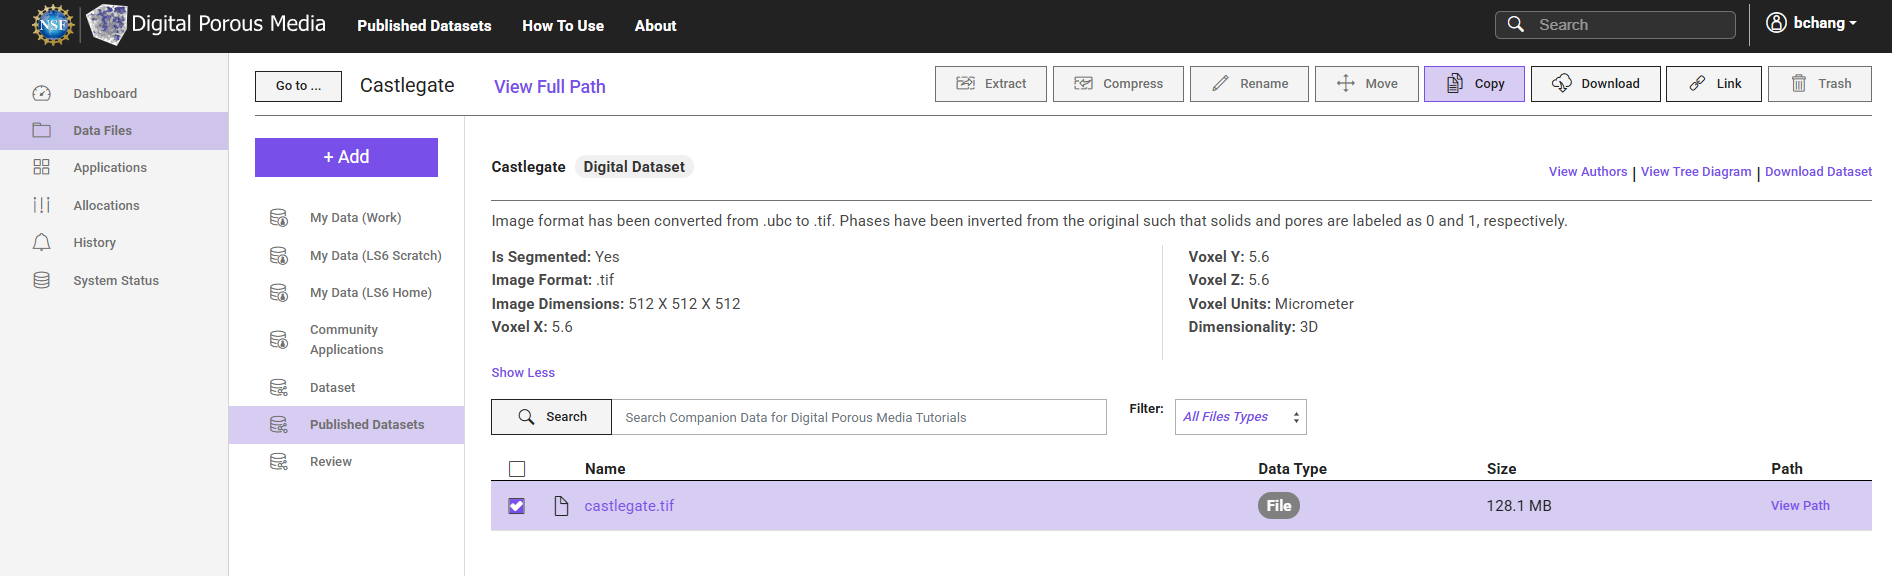

4. From the ``Destination`` dropdown, select ``My Data (Work)`` as the file system to copy the file to. You may copy your file into any subfolder within ``My Data (Work)``. 

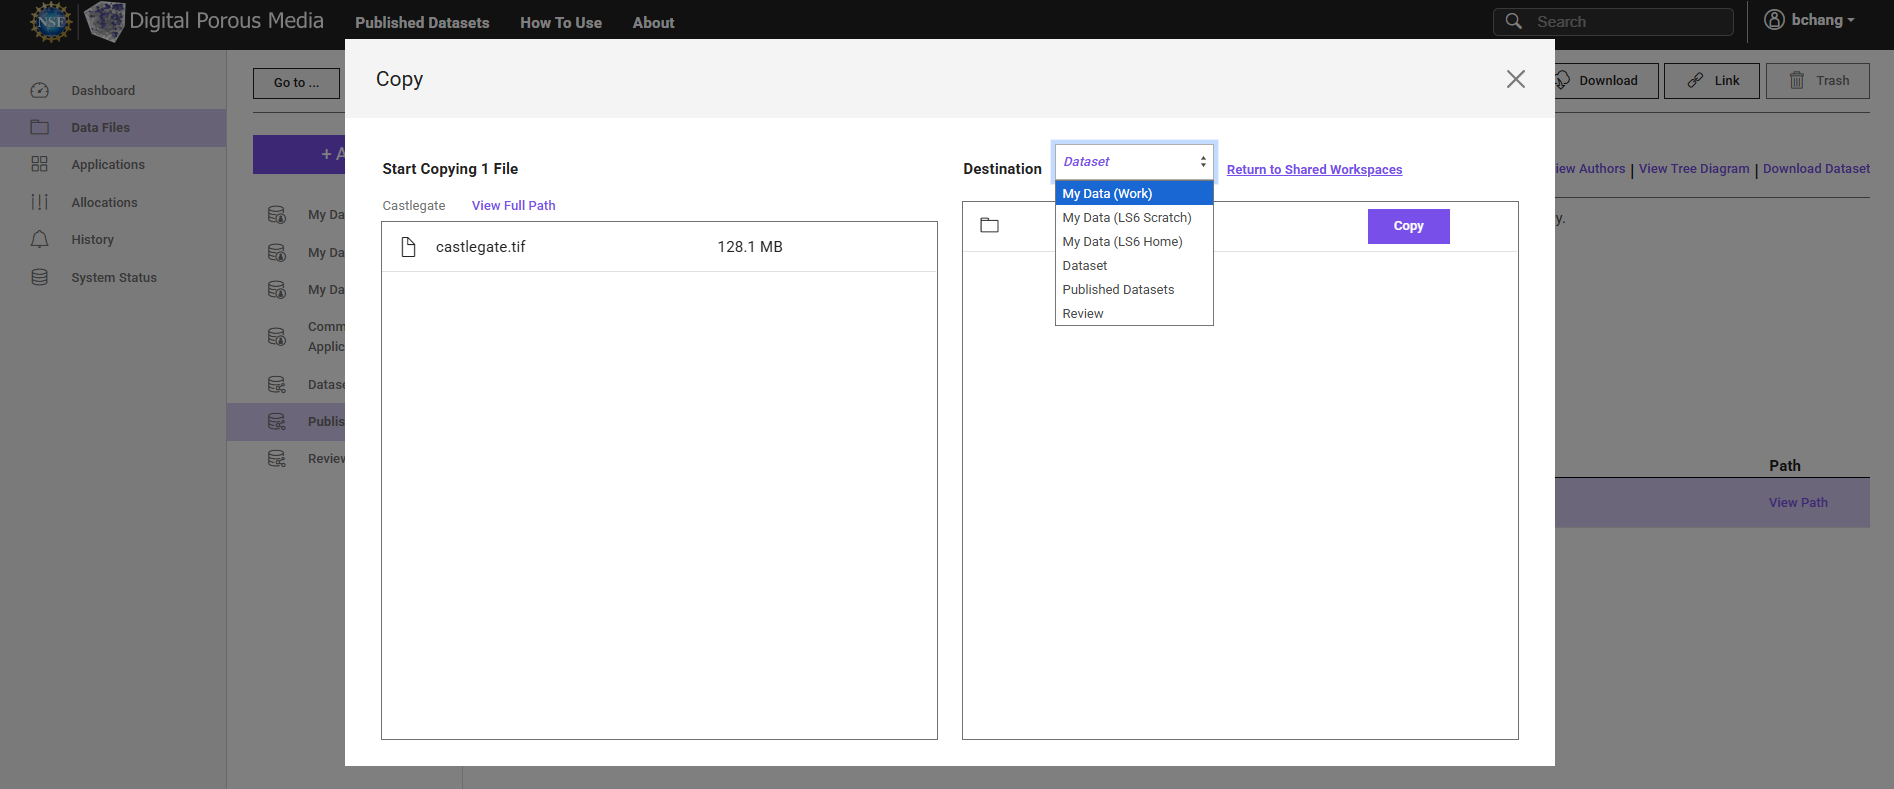

5. Once the file has been copied, you will find it on DPMP's JupyterHub instance under `/home/jovyan/work/...`

#### Option B: Download via URL in Python

If the file is publicly available (as all DPMP data is), you can download it directly in a notebook cell using ``urllib`` or your favorite HTTP library (e.g., ``requests``, ``httpx``, etc.):

```python
import urllib.request

url = "..."
destination = "/home/jovyan/work/.../your_file.tif"

urllib.request.urlretrieve(url, destination)
print(f"Downloaded to {destination}")
```

To find the download URL for a dataset image on DPMP:

1. Navigate to the image from the Published Datasets page

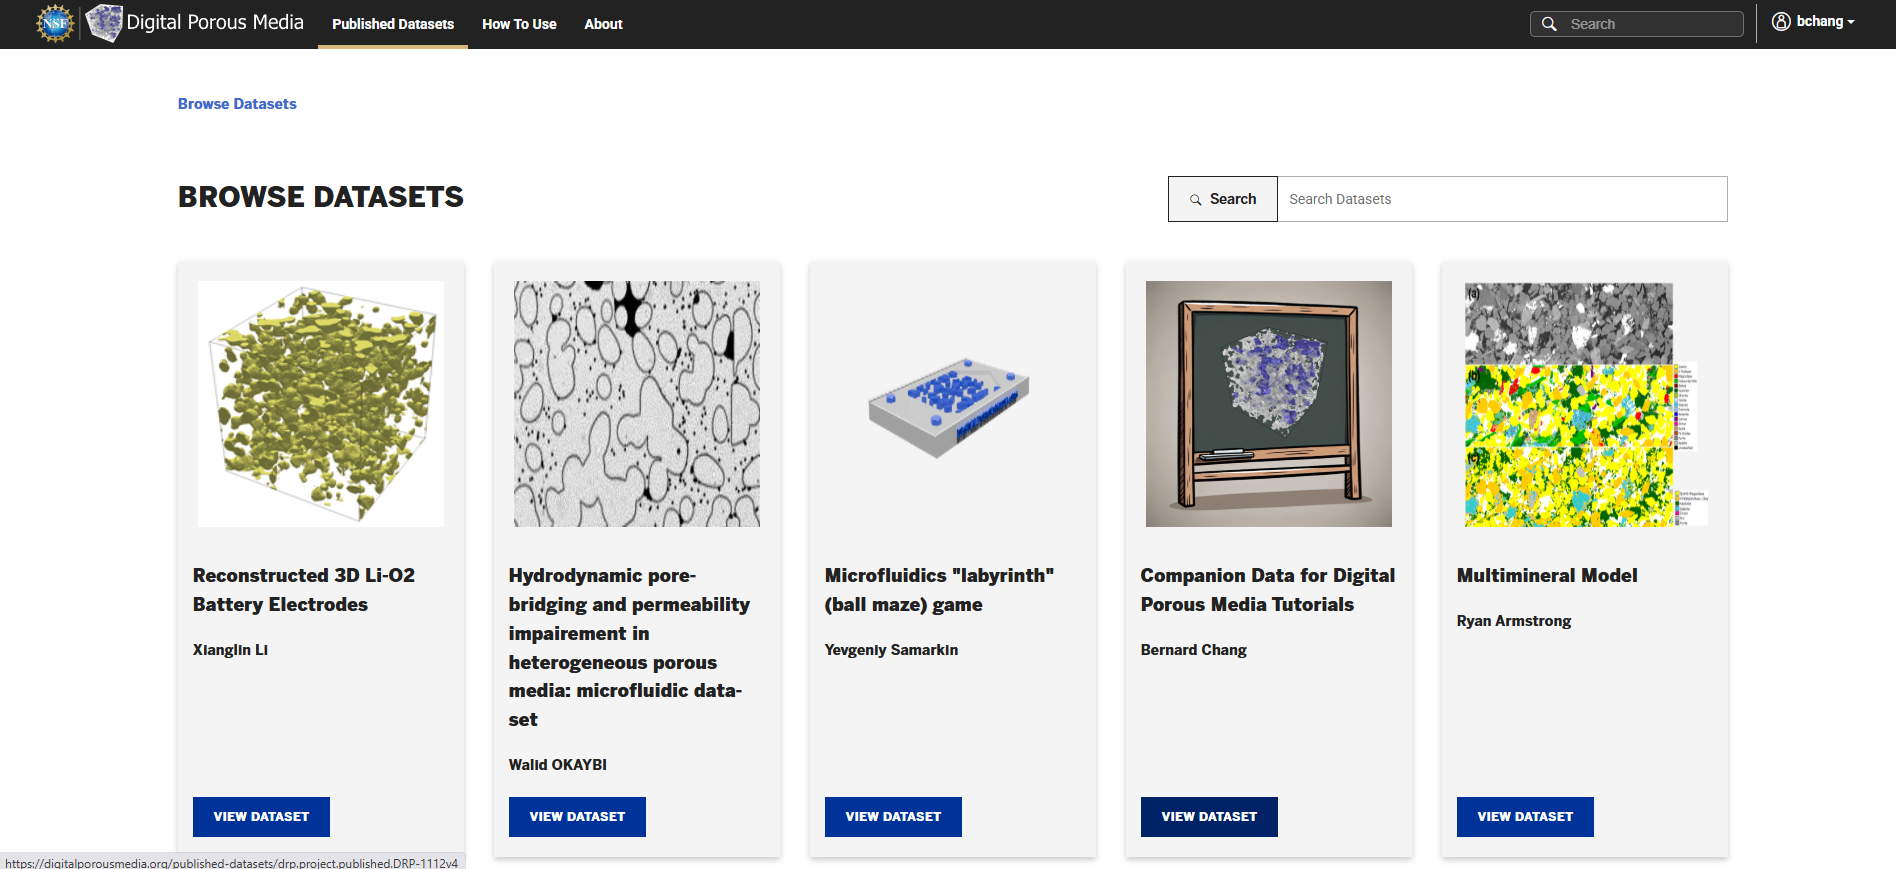

2. Under the Action button for the image you would like to use, **Right-Click** on the Download button and click ``Copy link address``

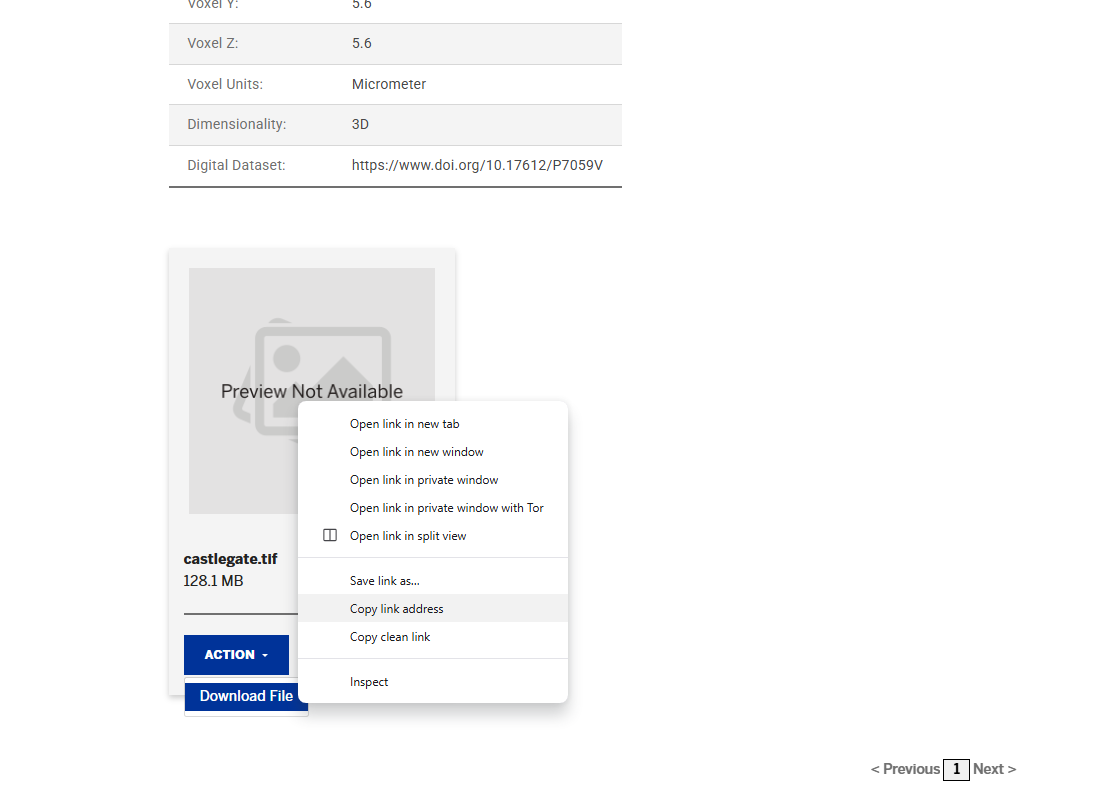

3. Paste under the ``url`` in the code block above. Be sure to update the destination path with your desired save location.

#### Option C: Upload from your local computer

1. In the JupyterHub file browser (left panel), navigate to your `work` directory

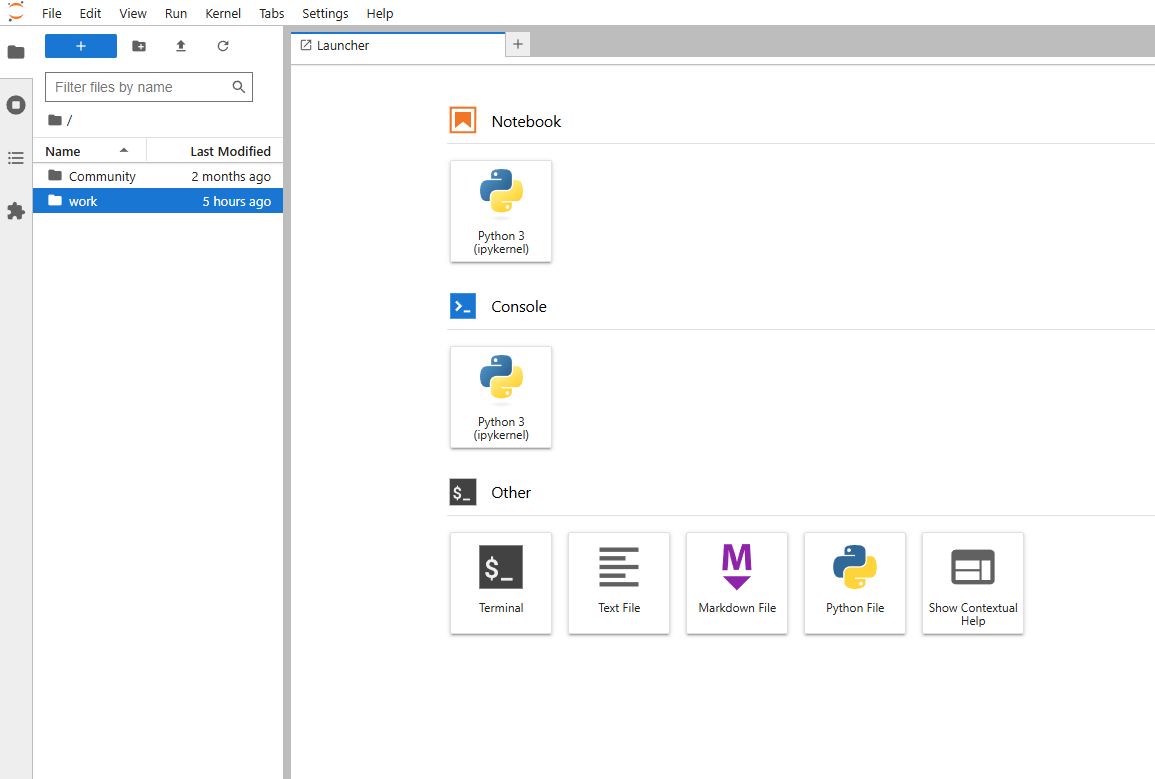

2. Click the **Upload** button (⬆️) in the toolbar

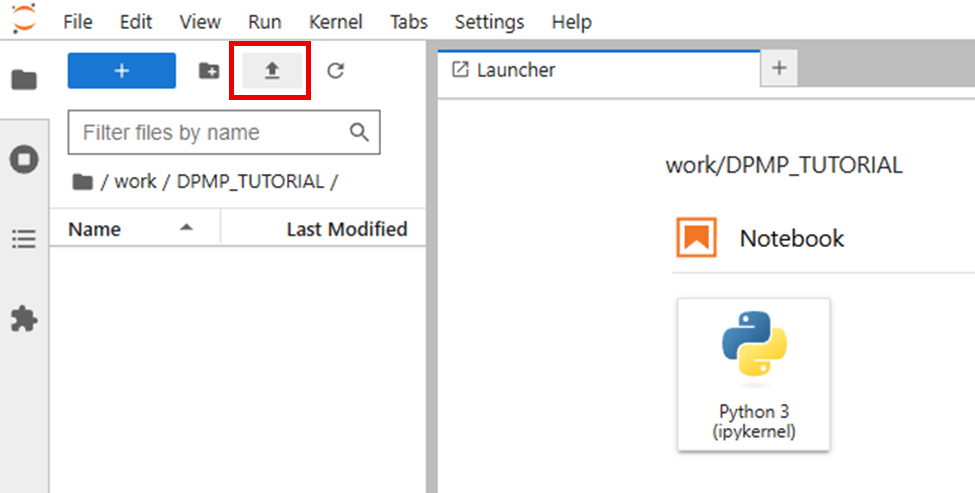

3. Select files from your computer
4. Once uploaded, the file path will be: `/home/jovyan/work/.../<filename>`

  #### Option D: Transfer via TACC shell and command-line tools

  If you have shell access to TACC HPC systems (e.g., via `ssh`), you can transfer files to your `$WORK` directory using standard command-line tools or graphical applications:

  **Command-line tools:**
  - `scp` — Copy files from your local machine to TACC
  - `rsync` — Synchronize directories (efficient for large transfers)
  - `ftp` — Traditional file transfer protocol

  **Graphical applications:**
  - `Globus` — High-performance data transfer service between institutions
  - `Cyberduck` (Mac/Windows/Linux) — Drag-and-drop SFTP/FTP client
  - `WinSCP` (Windows) — SFTP/SCP client with file browser interface

  Or directly move/copy files within the TACC filesystem if your data is already there.

  For detailed instructions, see the [TACC User Guide](https://docs.tacc.utexas.edu/datatransfer/datatransferguide/).

## Reading Your Transferred Data

Once your file is in a location you can access (local disk or `work` if on DPMP's JupyterHub), load it using an appropriate file reader such as `tifffile.imread()`. The specific function you use will depend on the file format.

Common examples from DPMP include:

 - TIFF (.tif, .tiff): `tifffile.imread()`
 - Raw binary (.raw): typically loaded with `numpy.fromfile()` (requires knowing dtype and shape)
 - HDF5 (.h5, .hdf5): `h5py.File()`
 - NetCDF (.nc): `xarray.open_dataset()` or `netCDF4.Dataset()`
 - PNG/JPEG (.png, .jpg): `imageio.imread()` or `PIL.Image.open()`

The output of the loading step should always be a NumPy array representing your image data, which can then be used consistently across the rest of the analysis workflow.

In [ ]:
# Replace this path with the actual location of your file
USER_IMAGE_PATH = "/path/to/your/image.tif"

# Update the following line if your image is not a TIFF file. The result of user_image should be a NumPy array. 
# For example, .raw files can be read as user_image = np.fromfile(USER_IMAGE_PATH, dtype=np.uint16).reshape((depth, height, width)) 
user_image = tifffile.imread(USER_IMAGE_PATH)
print(f"Shape: {user_image.shape}")
print(f"Data type: {user_image.dtype}")
print(f"Value range: [{user_image.min()}, {user_image.max()}]")

## Using Your Own Data in Tutorial Notebooks

Throughout the tutorials in this course, you will see data-loading lines like:

```python
# Load from tutorial registry
image = load_sample("sandpack")
```

or

```python
# Load from a path
image = tifffile.imread("/path/to/file.tif")
```

**To use your own data**, simply replace the data-loading line:

```python
# Change this:
image = load_sample("sandpack")

# To this:
image = tifffile.imread("/home/jovyan/work/.../my_image.tif")
```

All subsequent cells in the notebook will work the same way—they just operate on your array instead of the registry dataset.

## Next Steps

Now that you know how to access data, head over to:

- **[0-1: Introduction to 2D Images](0-1_introduction_2D_images.ipynb)** — Learn how to load, inspect, and visualize 2D grayscale and color images
- **[0-2: Introduction to 3D Images](0-2_introduction_3D_images.ipynb)** — Work with volumetric data and 3D visualization

Pick whichever matches your data type and jump in!